In [122]:
import numpy as np
import pandas as pd
import xarray as xr
import cfgrib

import utils
from package_name.evaluation import plots as eval_plots
from package_name.evaluation.utils import predict_clusters, compute_BSS_clusters_target_from_pca, compute_quantile_exceedance_BSS_from_pca, compute_BSS_clusters_target_from_vae, compute_quantile_exceedance_BSS_from_vae
from package_name.evaluation import metrics
from package_name.training.trainer import VAEConfig
from package_name.inference.predictor import VAEPredictor
from package_name.model.utils import sampling
from package_name.evaluation.pca_kmeans import PCAKmeansTrainer,  PCAKmeansPredictor


import matplotlib.pyplot as plt
plt.style.use('default')

In [123]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Parameters and Config


In [124]:
g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]
results_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/CH/"
data_path = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/wind/"
cluster_number = 8
original_dim = 575
pr_cluster_number = 8
batch_size = 128
epochs = 500

In [125]:
cluster_number = 8

config = VAEConfig(
    original_dim=original_dim,
    original_dim_target=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=10,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=sampling,
)

## Reanalysis Data loading and pre-processing

In [126]:
# load the dataframes for clusters and normalized data
df_target_clusters = pd.read_csv(data_path + "CH_8_clusters_norm.csv", index_col=0)
df_target = pd.read_csv(data_path + "CH_country_wise_norm.csv", index_col=0)

In [127]:
# Get training data
z500 = utils.preprocess_dataset(filename = "/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_data/z500/era5_z500_daily_250_atlantic_1940_2022.nc",
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = utils.GeographicalFilter.EXTENDED_EUROPE,
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
std_dev = z500.std()
z500 = z500/z500.std()

z500_reshaped = utils.reshape_data_for_clustering(z500)


# Get training data labels
target_labels = pd.read_csv(data_path + 'CH_8_clusters_norm.csv')
target_labels.columns = ['index', 'labels']

target_labels['values']=[1]*len(target_labels)
target_categorical_pd = pd.pivot_table(target_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
target_categorical = target_categorical_pd.values

In [128]:
#set data used for calculating climatology and conditional probabilites for testing
training_indices = np.where(z500['time.year'] <= 2024)[0]
testing_indices = np.where(z500['time.year'] > 2024)[0]

z500_training = z500[training_indices]
z500_testing = z500[testing_indices]

z500_reshaped_training = z500_reshaped[training_indices]
z500_reshaped_testing = z500_reshaped[testing_indices]

target_categorical_training = target_categorical[training_indices]
target_categorical_testing = target_categorical[testing_indices]

df_target_training = df_target.iloc[training_indices]
df_target_testing = df_target.iloc[testing_indices]

In [129]:
print("count of each label", target_categorical.sum(axis=0)/target_categorical.sum())

count of each label [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]


## Visualize clusters centers & target maps

In [130]:
def plot_run(run_id: int):
    """
    Plot mixture component centers, empirical cluster centers, and target variable for empirical cluster centers

    :param run_id: The ID of the run to plot
    """
    vae = VAEPredictor(cfg=config)
    weights_path = results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5"
    vae.load_weights(weights_path)

    cluster_probabilities = predict_clusters(vae=vae, inputs=z500_training.values)
    cluster_labels = np.argmax(cluster_probabilities, axis=1)
    z500_with_label = z500_training.assign_coords(cluster=("time", cluster_labels))

    #order clusters by how often they occur in the data
    label_counts = np.bincount(z500_with_label.cluster.values)
    label_order = np.argsort(label_counts)[::-1]  # Sort in descending order

    #call plotting functions
    fig_cluster_centers = eval_plots.plot_cluster_centers(
        vae,
        z500[0],
        #plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    fig_empirical_cluster_centers = eval_plots.plot_empirical_cluster_centers(
        z500_with_label,
        #plot_reordering=label_order,
        levels=np.arange(-2.0, 2.1, 0.25),
    )

    column_labels = df_target_training.columns.astype(str).tolist()

    cluster_label_df = pd.DataFrame({'labels':cluster_labels})
    

199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


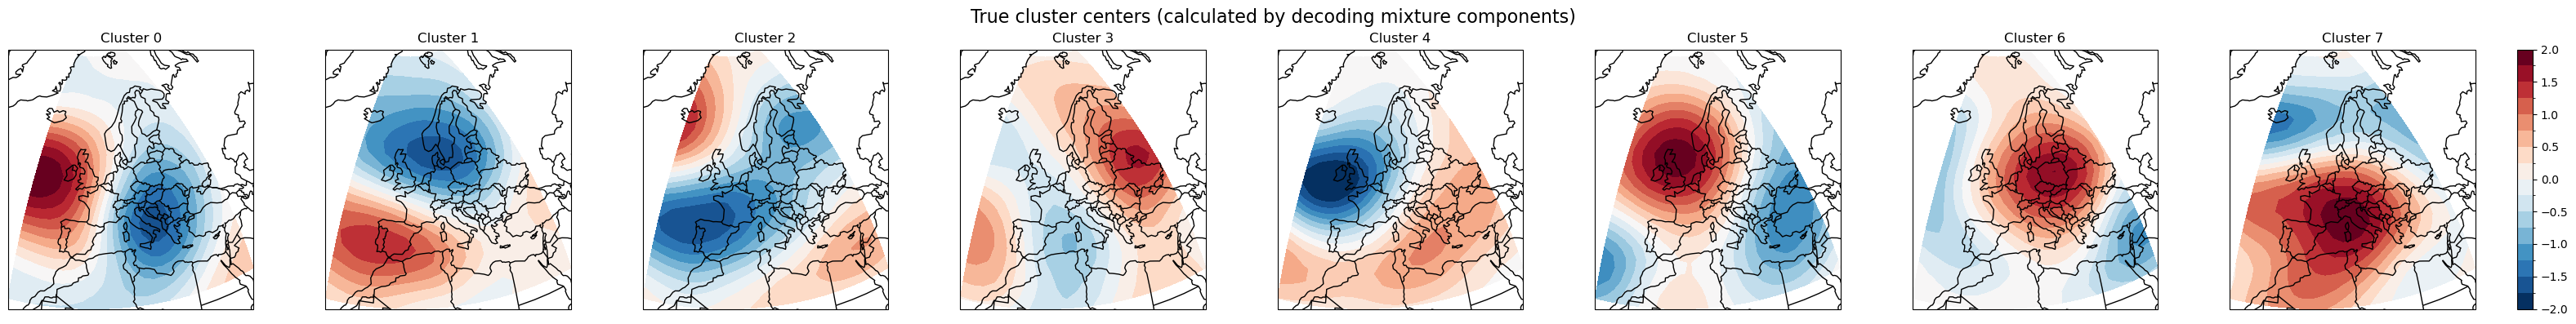

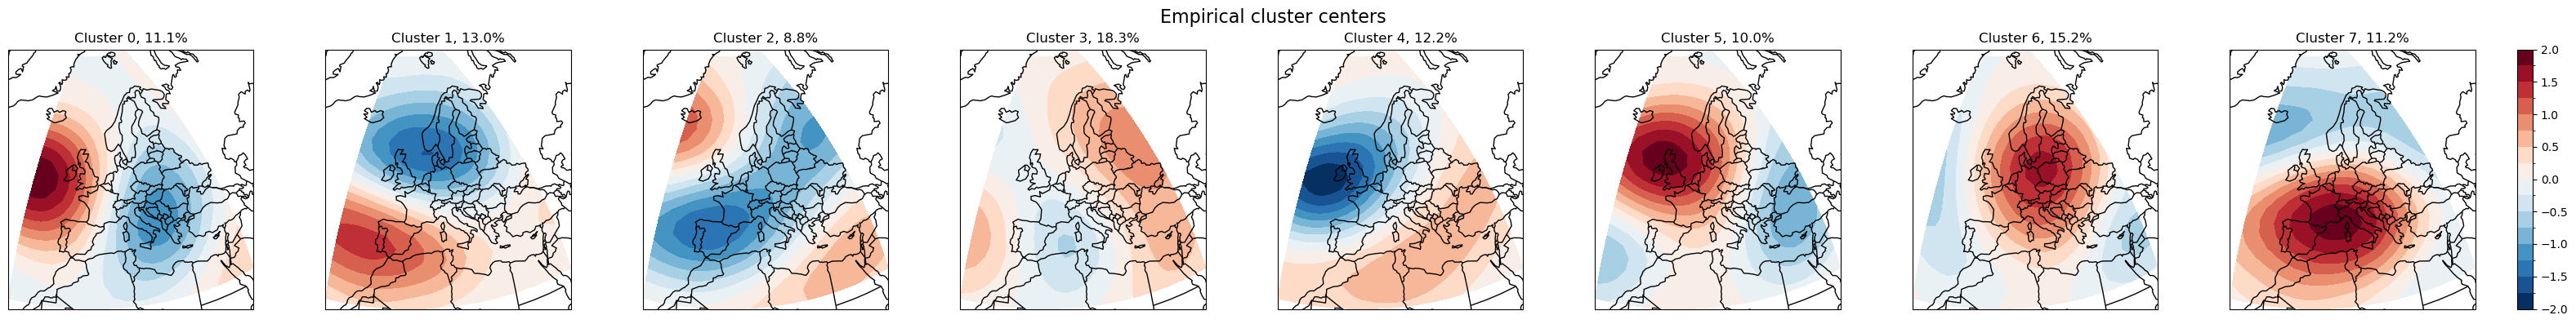

In [131]:
plot_run(run_id=2)

## Evaluation with Hindcast Data


In [93]:
#load all seasonal forecasts for 2004-2020 starting on JF, 1, 8, 15, 22
for month in [1, 2]:
    for day in [1, 8, 15, 22]:
        mem_ds = xr.open_dataset(
            "/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s/plev_data_perturbed_members_2004" + str(month).zfill(2) + str(day).zfill(2) + "-2020" + str(month).zfill(2) + str(day).zfill(2) + ".grb",
            engine="cfgrib",
        )
        con_ds = xr.open_dataset(
            "/net/helium/atmosdyn/vselvakumar/Data/C4E/Energy_var/s2s/plev_data_unperturbed_control_member_2004" + str(month).zfill(2) + str(day).zfill(2) + "-2020" + str(month).zfill(2) + str(day).zfill(2) + ".grb",
            engine="cfgrib",
        )

        ds_all = xr.concat([mem_ds, con_ds], dim="number")

        ds_days_anom_temp = utils.preprocess_forecast_data(
                dataset=ds_all,
                variable_name="gh",
                multiplication_factor=1.0,
                geographical_filter=utils.GeographicalFilter.EXTENDED_EUROPE,
                anomalies=True,
                normalization=False,
                rolling_window=5,
                spatial_resolution=2.5,
                #weights=weights,
                ) 

        if month == 1 and day == 1:
            ds_days_anom = ds_days_anom_temp
        else:
            ds_days_anom = xr.concat([ds_days_anom, ds_days_anom_temp], dim="time")

        print("Finished processing month:", month, "day:", day)

Finished processing month: 1 day: 1
Finished processing month: 1 day: 8
Finished processing month: 1 day: 15
Finished processing month: 1 day: 22
Finished processing month: 2 day: 1
Finished processing month: 2 day: 8
Finished processing month: 2 day: 15
Finished processing month: 2 day: 22


In [94]:
time_pd = pd.to_datetime(ds_days_anom["time"].values)
delta_time_pd = pd.to_timedelta(ds_days_anom["days"], unit="D")

ds_days_anom = ds_days_anom.assign_coords(
    valid_time=(("time", "days"), np.empty((len(time_pd), len(delta_time_pd)), dtype="datetime64[ns]"))
)

for i in range(len(time_pd)):
    for j in range(len(delta_time_pd)):
        ds_days_anom["valid_time"][i, j] = time_pd[i] + delta_time_pd[j]

In [154]:
z500_hind_all_members = ds_days_anom.isel(days=14).gh 
z500_hind_all_members = z500_hind_all_members * weights
z500_hind_all_members = z500_hind_all_members/std_dev

In [155]:
valid_times = z500_hind_all_members["valid_time"]
testing_indices_hindcast = np.where(valid_times.dt.year >= 2000)[0]

In [156]:
#format input data for testing
z500_hind_all_members_testing = z500_hind_all_members.isel(time=testing_indices_hindcast)
z500_hind_all_members_testing = z500_hind_all_members_testing.transpose('time', 'number', 'latitude', 'longitude')
valid_times_testing = z500_hind_all_members_testing["valid_time"]

In [157]:
#select the corresponding indices for era5 energy data
time_values = z500["time"].values

time_to_index = {t: i for i, t in enumerate(time_values)}
target_indices_hindcast_testing = np.array([time_to_index[t] for t in valid_times_testing.values])
target_categorical_hindcast_testing = target_categorical[target_indices_hindcast_testing]

df_target_hindcast_testing = df_target.iloc[target_indices_hindcast_testing]


## Informativeness metrics

In [158]:
def get_skill_scores(metric_func: callable, n_runs: int) -> np.ndarray:
    """Compute skill scores for various versions of the target variable.

    :param metric_func: Function to compute a skill score. It should take a VAEPredictor as input and return a float.
    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each run.
    """
    vae = VAEPredictor(cfg=config)
    scores = []
    for run_id in range(n_runs):
        vae.load_weights(results_path + f"final_weights_{vae.cfg.cluster_number}_{run_id}.weights.h5")
        bss = metric_func(vae)
        scores.append(bss)

    return np.array(scores)


def get_skill_scores_for_all_metrics(n_runs: int = 10) -> np.ndarray:
    """Compute the Brier skill scores for precipitation clusters, 5th percentile exceedance, and precipitation terciles.

    :param n_runs: Number of runs to compute the skill scores for.
    :return: Array of Brier skill scores for each metric and each run.
    """

    metric_funcs = [lambda vae: compute_BSS_clusters_target_from_vae(vae=vae, 
    input_test=z500_hind_all_members_testing.values, 
    targets_categorical_test=target_categorical_hindcast_testing, 
    input_climatology=z500_training.values, 
    targets_categorical_climatology=target_categorical_training),
                    lambda vae: compute_quantile_exceedance_BSS_from_vae(vae=vae,
    input_test=z500_hind_all_members_testing.values,
    target_test=df_target_hindcast_testing.values,
    input_climatology=z500_training.values,
    target_climatology=df_target_training.values,
    q=0.125,
    larger_than=False)
                    ]

    metric_names = ["Brier skill score\nfor wind energy clusters",
                     "Brier skill score\nfor being lower than 12.5th\npercentile",
                     #"Brier skill score\nfor terciles per grid point"
                     ]
    
    n_metrics = len(metric_funcs)
    scores = np.zeros((n_metrics, n_runs))

    for metric_id in range(n_metrics):
        scores[metric_id] = get_skill_scores(metric_funcs[metric_id], n_runs)

    return scores, metric_names


In [159]:
scores, metric_names = get_skill_scores_for_all_metrics()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
199/199 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1

### Get clusters with PCA + k-means

In [160]:
#train PCA + KMeans model on ERA5 training data

X_train = z500_reshaped_training
X_test = utils.reshape_data_for_clustering(z500_hind_all_members_testing)

pca_kmeans_trainer = PCAKmeansTrainer(n_clusters=cluster_number, n_components=15, model_dir="/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/PCA/")

cluster_probs_train, info = pca_kmeans_trainer.cluster(x=X_train)
pca_kmeans_trainer.save_models(info)


pca_kmeans_predictor = PCAKmeansPredictor(model_dir="/net/nitrogen/atmosdyn/zilnora/code_for_earth/our_results/PCA/")
#cluster_probs_train_pca = pca_kmeans_predictor.clusters(x=X_train)
#cluster_probs_test_pca = pca_kmeans_predictor.clusters(x=X_test)

In [161]:
scores_pca = np.zeros((2, 1))

scores_pca[0] = compute_BSS_clusters_target_from_pca(pca_kmeans_predictor=pca_kmeans_predictor,
    input_test=z500_hind_all_members_testing.values,
    targets_categorical_test=target_categorical_hindcast_testing,
    input_climatology=z500_training.values,
    targets_categorical_climatology=target_categorical_training)

scores_pca[1] = compute_quantile_exceedance_BSS_from_pca(pca_kmeans_predictor=pca_kmeans_predictor,
    input_test=z500_hind_all_members_testing.values,
    target_test=df_target_hindcast_testing.values,
    input_climatology=z500_training.values,
    target_climatology=df_target_training.values,
    q=0.125,
    larger_than=False)

### Plot scores

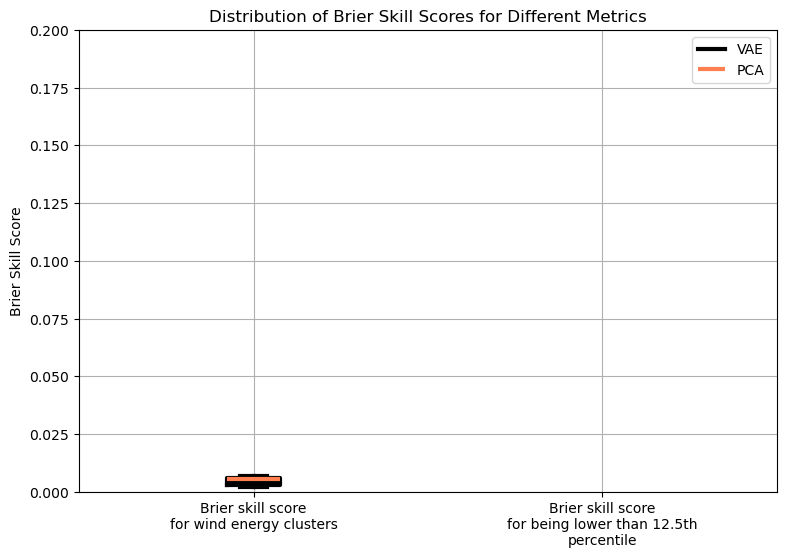

In [162]:
_, ax = plt.subplots(1, 1, figsize=(9, 6))
#not frozen
# Box and whisker plots

props = dict(linewidth=3, color='k')
vae_box = ax.boxplot(
    scores.T[:], 
    boxprops=props, 
    medianprops=props,
    whiskerprops=props,  # Thicker vertical lines
    capprops=props,       # Thicker horizontal end caps
)


# add pca line in red
props = dict(linewidth=3, color='coral')
pca_box = ax.boxplot(
    scores_pca.reshape(-1, 1).T,
    medianprops=props,
)

ax.set_xticks(range(1, len(metric_names) + 1))
ax.set_xticklabels(metric_names, rotation=0, ha='center')
ax.legend([vae_box["boxes"][0], pca_box["medians"][0]], ["VAE", "PCA"], loc="upper right")
ax.set_title("Distribution of Brier Skill Scores for Different Metrics")
ax.set_ylabel("Brier Skill Score")
ax.set_ylim(0,0.2)
ax.grid()

